In [1]:
import torch
from torch import nn
from torch.utils.data import Dataset

import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

import numpy as np 
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

print(torch.__version__)
print(torchvision.__version__)

2.5.1
0.20.1


In [2]:
x = torch.rand(3, 3)
print(x.device)    # Output: cpu
print(x.is_cuda)  # Output: False

cpu
False


In [3]:
train_data = datasets.OxfordIIITPet(
    root="data",
    split="trainval",
    download=True,
    transform=torchvision.transforms.ToTensor(),
    target_transform=None
)

test_data = datasets.OxfordIIITPet(
    root="data",
    split="test",
    download=True,
    transform=torchvision.transforms.ToTensor(),
    target_transform=None
)

In [4]:
len(train_data), len(test_data)

(3680, 3669)

In [5]:
img, label = train_data[2]
img, label

(tensor([[[0.5765, 0.5686, 0.5725,  ..., 0.4431, 0.4431, 0.4706],
          [0.5647, 0.5686, 0.5765,  ..., 0.3922, 0.3843, 0.4353],
          [0.5765, 0.5647, 0.5686,  ..., 0.3451, 0.3490, 0.4039],
          ...,
          [0.1882, 0.1765, 0.1882,  ..., 0.9059, 0.9098, 0.8941],
          [0.1529, 0.1765, 0.1725,  ..., 0.9255, 0.9412, 0.9294],
          [0.2157, 0.2000, 0.2000,  ..., 0.9333, 0.8980, 0.9020]],
 
         [[0.5098, 0.5020, 0.5098,  ..., 0.4471, 0.4314, 0.4588],
          [0.5020, 0.5059, 0.5137,  ..., 0.4196, 0.4078, 0.4471],
          [0.5137, 0.5020, 0.5059,  ..., 0.3961, 0.3882, 0.4431],
          ...,
          [0.0353, 0.0157, 0.0275,  ..., 0.7294, 0.6980, 0.6980],
          [0.0000, 0.0118, 0.0000,  ..., 0.7333, 0.7098, 0.7137],
          [0.0941, 0.0824, 0.0824,  ..., 0.7569, 0.7216, 0.7294]],
 
         [[0.4471, 0.4392, 0.4471,  ..., 0.1333, 0.1686, 0.1961],
          [0.4392, 0.4431, 0.4510,  ..., 0.1059, 0.1333, 0.1765],
          [0.4549, 0.4431, 0.4471,  ...,

In [6]:
class_names = train_data.classes
len(class_names), print(class_names)

['Abyssinian', 'American Bulldog', 'American Pit Bull Terrier', 'Basset Hound', 'Beagle', 'Bengal', 'Birman', 'Bombay', 'Boxer', 'British Shorthair', 'Chihuahua', 'Egyptian Mau', 'English Cocker Spaniel', 'English Setter', 'German Shorthaired', 'Great Pyrenees', 'Havanese', 'Japanese Chin', 'Keeshond', 'Leonberger', 'Maine Coon', 'Miniature Pinscher', 'Newfoundland', 'Persian', 'Pomeranian', 'Pug', 'Ragdoll', 'Russian Blue', 'Saint Bernard', 'Samoyed', 'Scottish Terrier', 'Shiba Inu', 'Siamese', 'Sphynx', 'Staffordshire Bull Terrier', 'Wheaten Terrier', 'Yorkshire Terrier']


(37, None)

In [12]:
class SRDataset(Dataset):

    def __init__(
            self, base_data, image_size = (128,128), scale_factor = 4
    ):
        
        self.dataset = base_data
        
        self.scale_factor = scale_factor

        self.resize = transforms.Resize((image_size))

        self.crop = transforms.RandomCrop((64,64))

        self.ToTensor = transforms.ToTensor()

        self.inputs = []
        self.targets = []

        print("preprocessing....")


        for img, _ in tqdm(base_data):
            img = transforms.ToPILImage()(img).convert("RGB")

            img = self.resize(img)
            img = self.crop(img)
            w,h = img.size
           
            lr_img = img.resize((w//self.scale_factor, h//self.scale_factor), Image.BICUBIC)

            bicubic_img = lr_img.resize((w,h), Image.BICUBIC)

            self.inputs.append(self.ToTensor(bicubic_img))
            self.targets.append(self.ToTensor(img))

        print("Done!")

    def __len__(self):

        return len(self.inputs)

    
    def __getitem__(self, idx):

        return self.inputs[idx], self.targets[idx]

In [13]:
from torch.utils.data import DataLoader

sr_train_data = SRDataset(train_data, image_size=(256,256), scale_factor=2)

train_dataloader = DataLoader(
    sr_train_data,
    batch_size = 32,
    shuffle = True,
    pin_memory=True
)

preprocessing....


100%|██████████| 3680/3680 [00:32<00:00, 114.95it/s]

Done!


In [69]:
class SRCNN(nn.Module):

    def __init__(self):
        super(SRCNN, self).__init__()

        

        self.layer1 = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=9, padding=4)

        self.layer2 = nn.Conv2d(in_channels=64, out_channels=32, kernel_size=5, padding=2)

        self.layer3 = nn.Conv2d(in_channels=32, out_channels=3, kernel_size=5, padding=2)

        self.relu = nn.ReLU()

    
    def forward(self, x):
        residual = x
        
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.layer3(x)

        return x + residual


In [70]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [71]:
model = SRCNN().to(device = device)
criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
num_epoch = 150

scaler = torch.cuda.amp.GradScaler()
epoch_loss= []
for epoch in range(num_epoch):
    model.train()
    running_loss = 0.0
    
    for inputs, targets in train_dataloader:

        inputs = inputs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        optimizer.zero_grad()
        with torch.cuda.amp.autocast():

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            
            running_loss += loss.item()

    avg_loss = running_loss/ len(train_dataloader)
    epoch_loss.append(avg_loss)
    print(f"Epoch [{epoch+1}/{num_epoch}] Loss: {avg_loss:.4f}")


C:\Users\suryansh\AppData\Local\Temp\ipykernel_1732\4247305075.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
C:\Users\suryansh\AppData\Local\Temp\ipykernel_1732\4247305075.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch [1/150] Loss: 0.0176
Epoch [2/150] Loss: 0.0157
Epoch [3/150] Loss: 0.0152
Epoch [4/150] Loss: 0.0149
Epoch [5/150] Loss: 0.0147
Epoch [6/150] Loss: 0.0146
Epoch [7/150] Loss: 0.0145
Epoch [8/150] Loss: 0.0144
Epoch [9/150] Loss: 0.0144
Epoch [10/150] Loss: 0.0143
Epoch [11/150] Loss: 0.0142
Epoch [12/150] Loss: 0.0142
Epoch [13/150] Loss: 0.0142
Epoch [14/150] Loss: 0.0141
Epoch [15/150] Loss: 0.0141
Epoch [16/150] Loss: 0.0141
Epoch [17/150] Loss: 0.0140
Epoch [18/150] Loss: 0.0140
Epoch [19/150] Loss: 0.0140
Epoch [20/150] Loss: 0.0140
Epoch [21/150] Loss: 0.0140
Epoch [22/150] Loss: 0.0139
Epoch [23/150] Loss: 0.0139
Epoch [24/150] Loss: 0.0139
Epoch [25/150] Loss: 0.0139
Epoch [26/150] Loss: 0.0139
Epoch [27/150] Loss: 0.0138
Epoch [28/150] Loss: 0.0138
Epoch [29/150] Loss: 0.0138
Epoch [30/150] Loss: 0.0138
Epoch [31/150] Loss: 0.0138
Epoch [32/150] Loss: 0.0138
Epoch [33/150] Loss: 0.0138
Epoch [34/150] Loss: 0.0137
Epoch [35/150] Loss: 0.0137
Epoch [36/150] Loss: 0.0137
E

In [72]:
print(f"Input shape:  {inputs.shape}")
print(f"Output shape: {outputs.shape}")
print(f"Target shape: {targets.shape}")

Input shape:  torch.Size([32, 3, 64, 64])
Output shape: torch.Size([32, 3, 64, 64])
Target shape: torch.Size([32, 3, 64, 64])


In [ ]:
plt.plot(epoch_loss)
plt.xlabel("no. of epochs")
if isinstance(criterion, nn.L1Loss):
    plt.ylabel("L1 LOSS")

else:
    plt.ylabel("MSE LOSS")

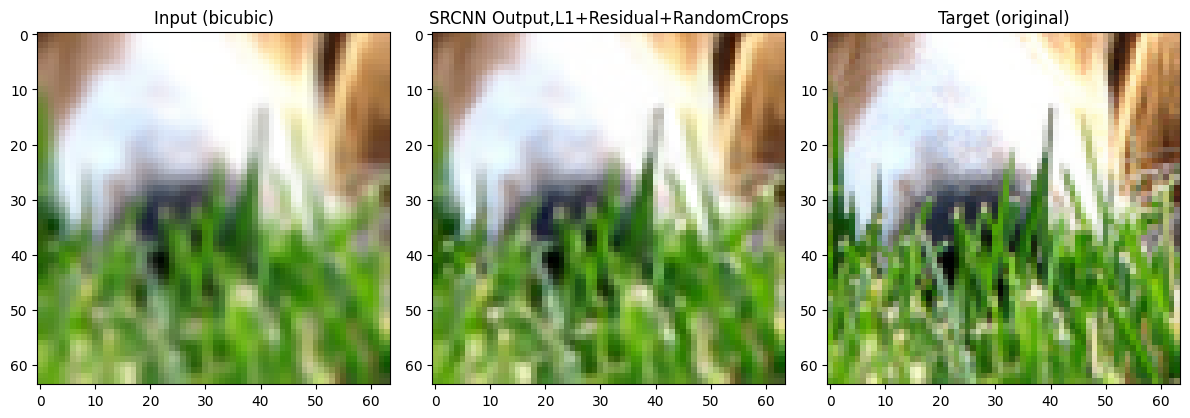

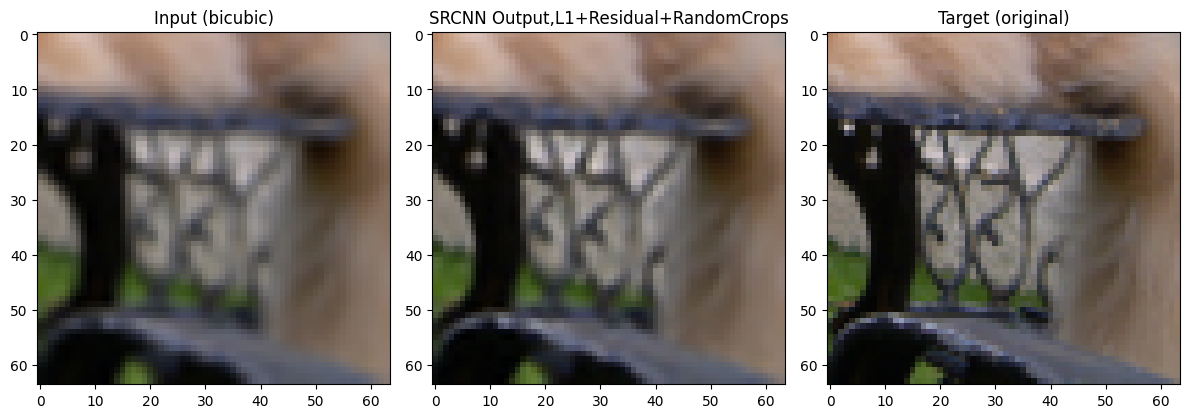

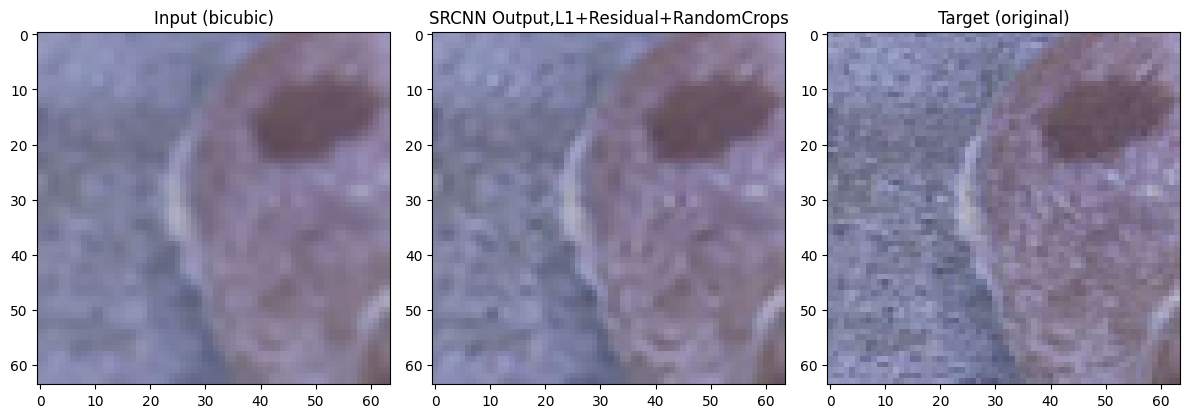

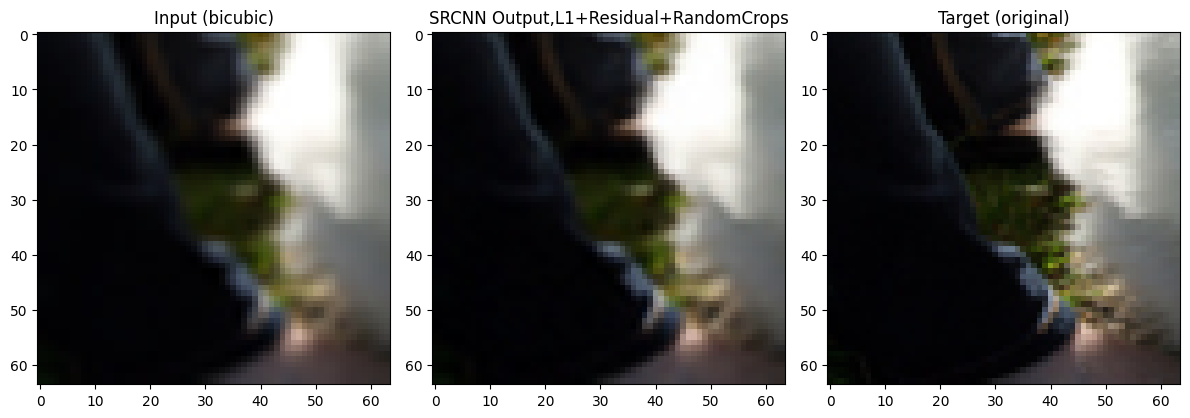

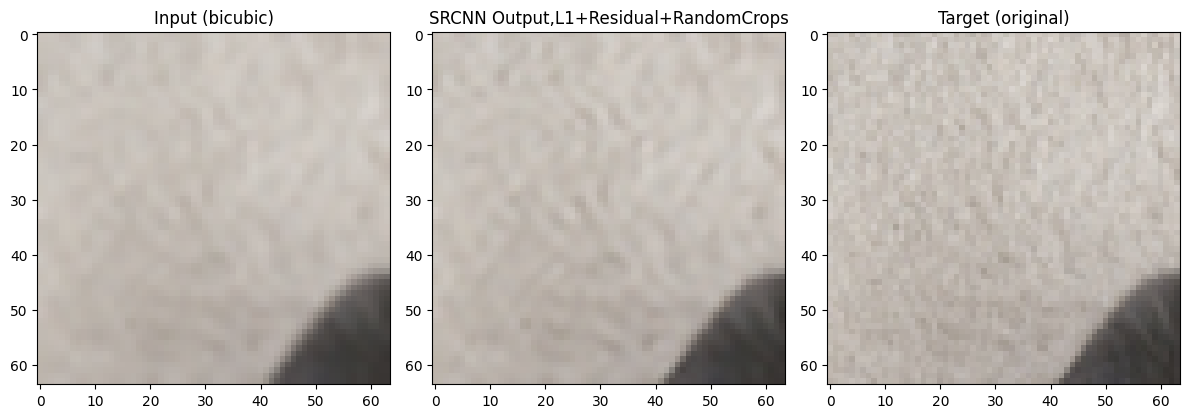

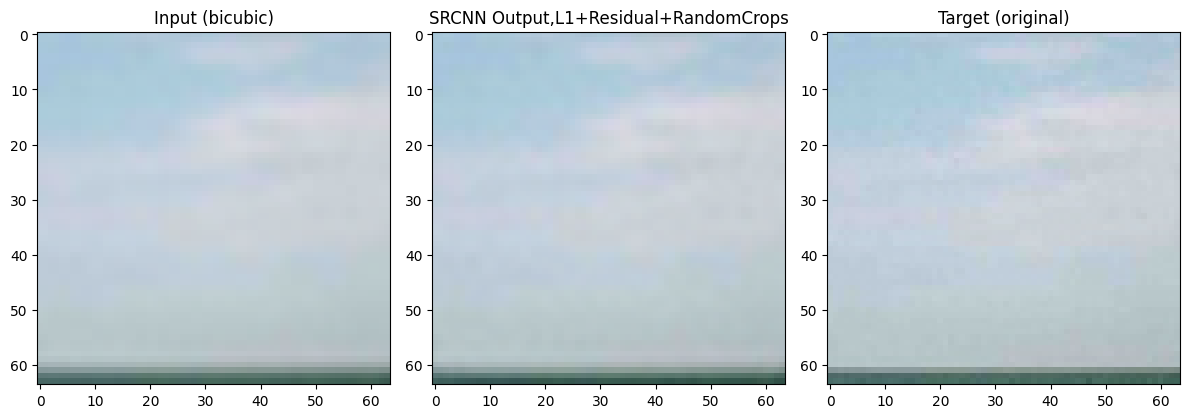

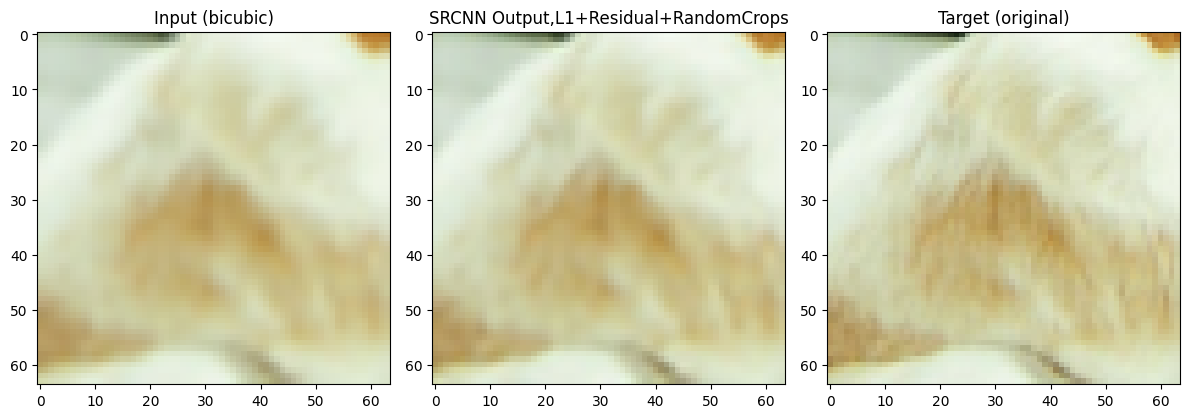

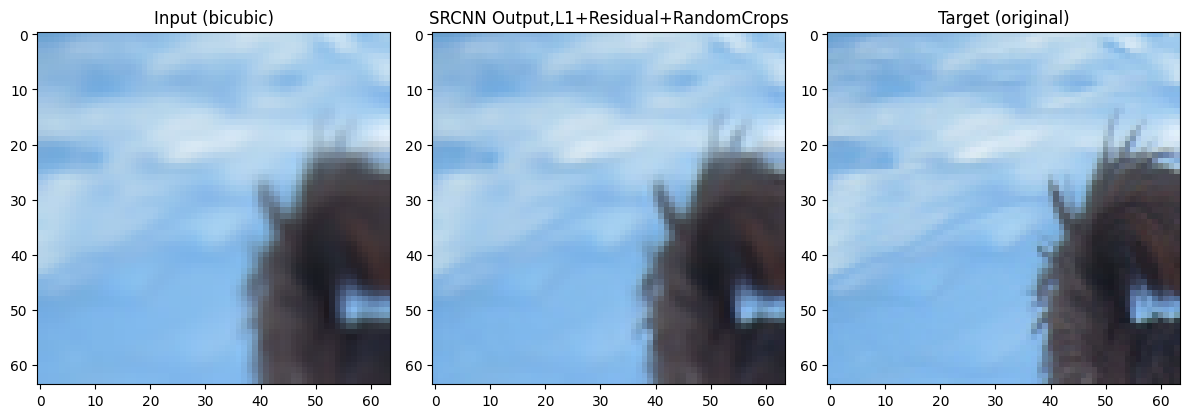

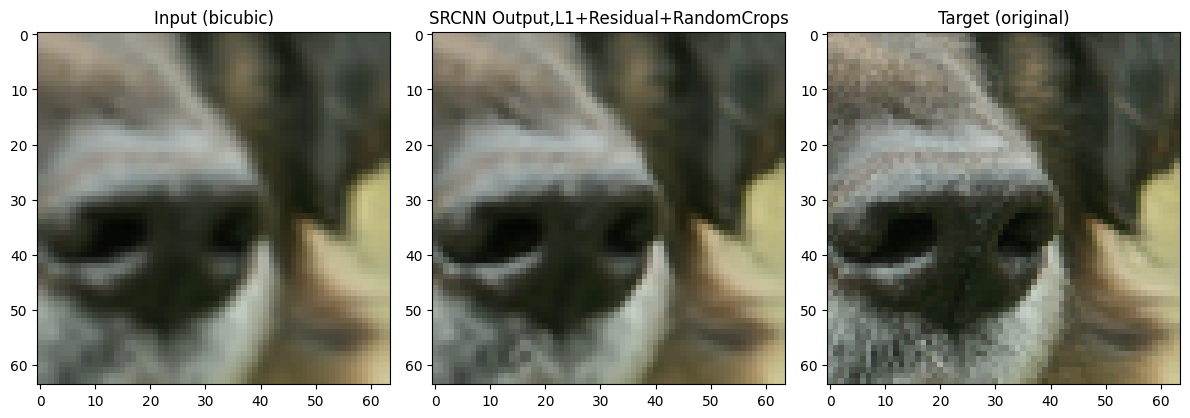

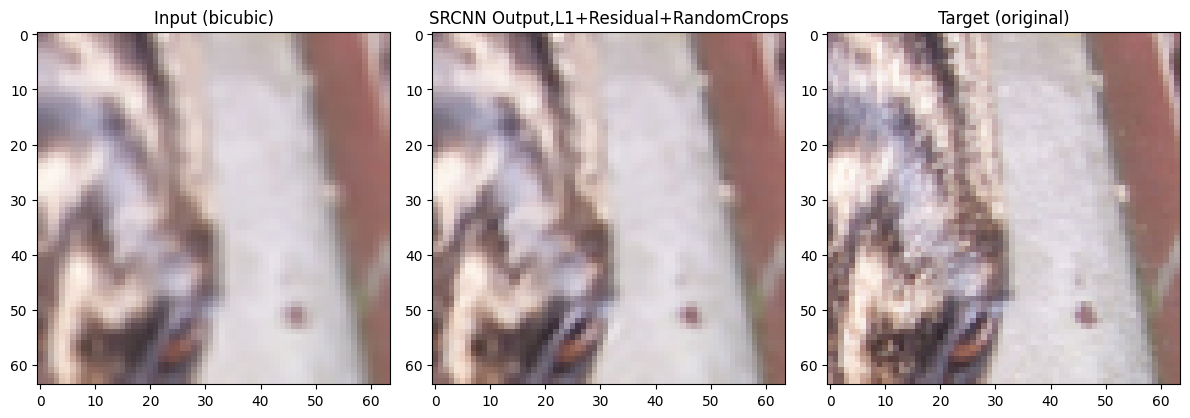

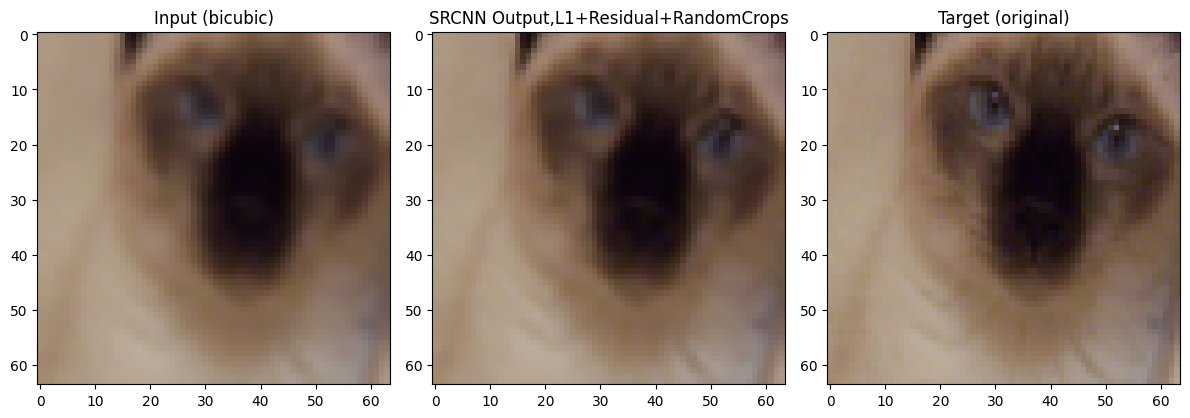

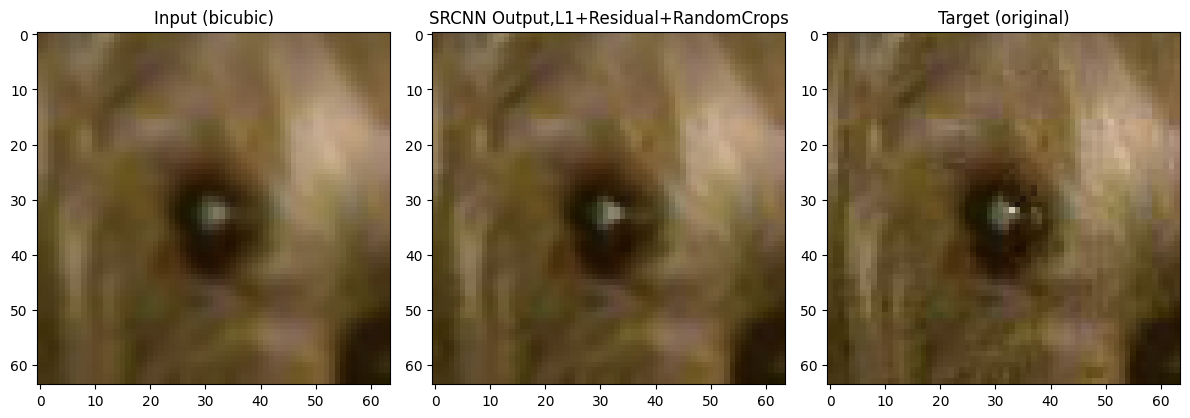

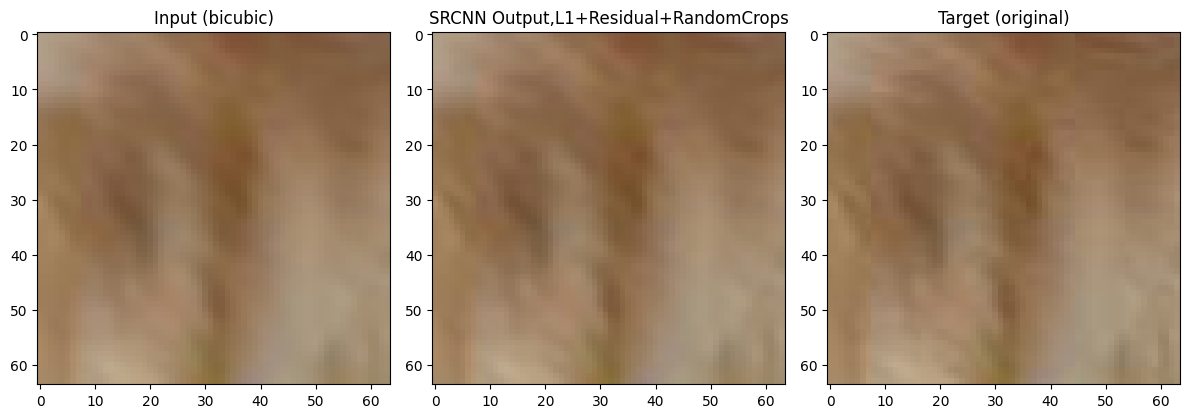

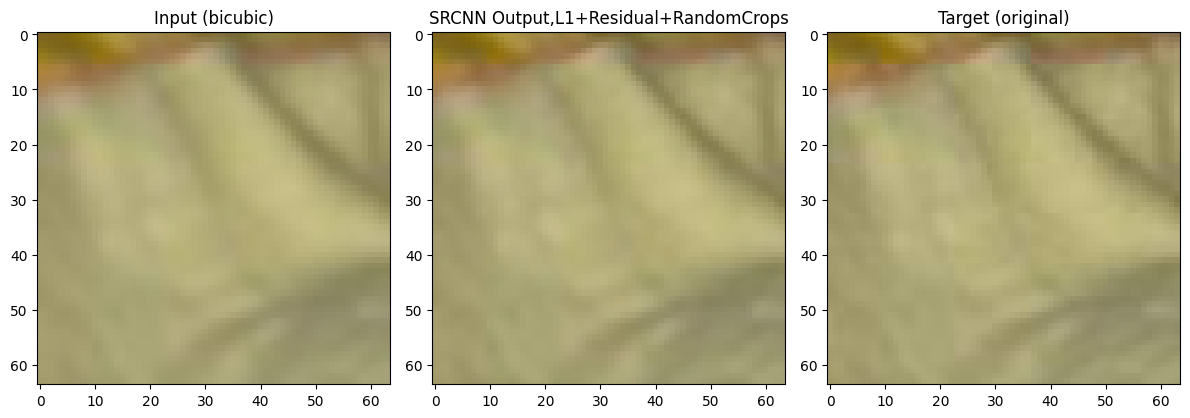

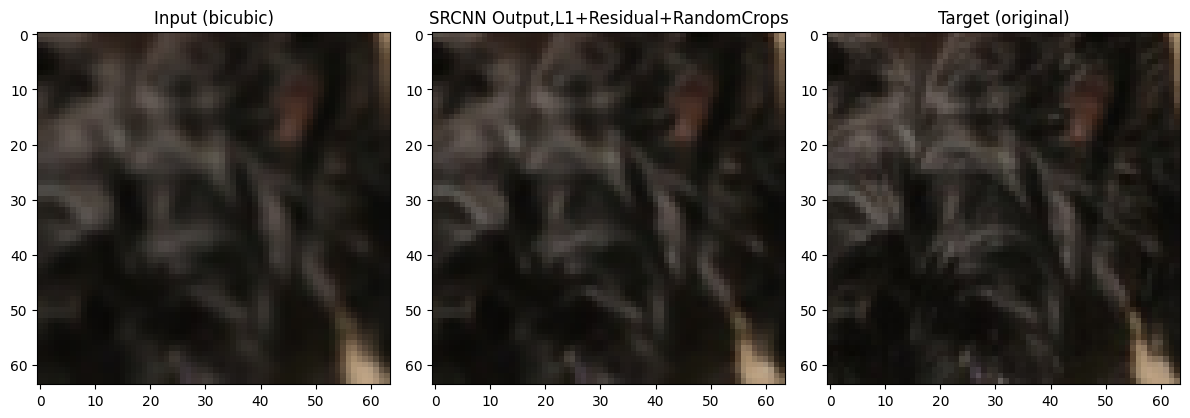

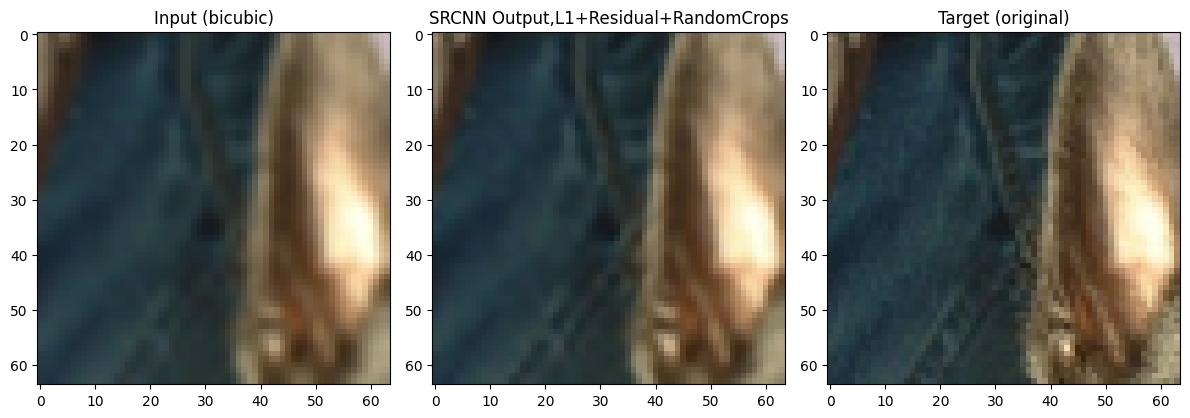

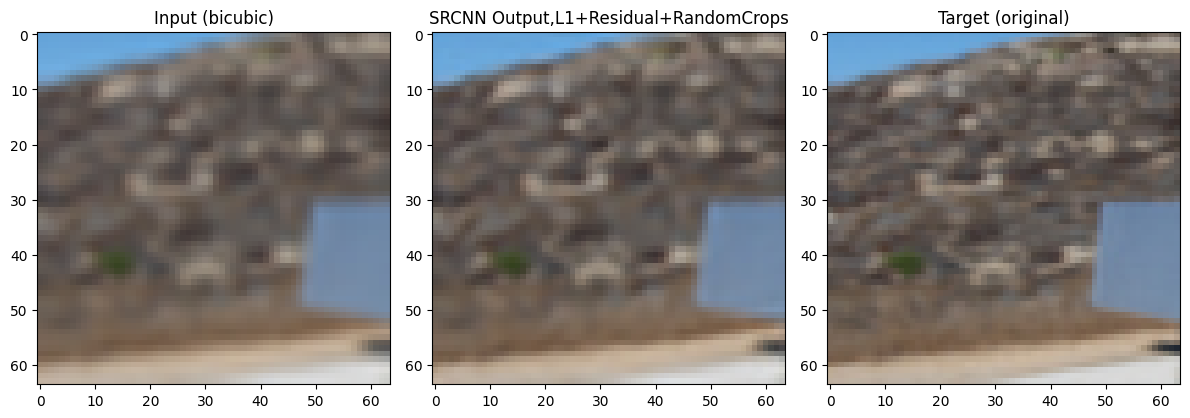

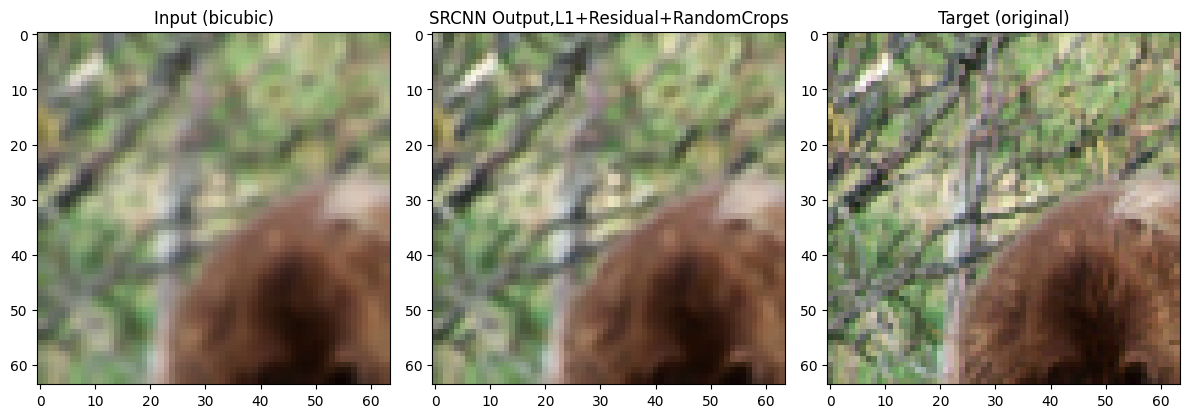

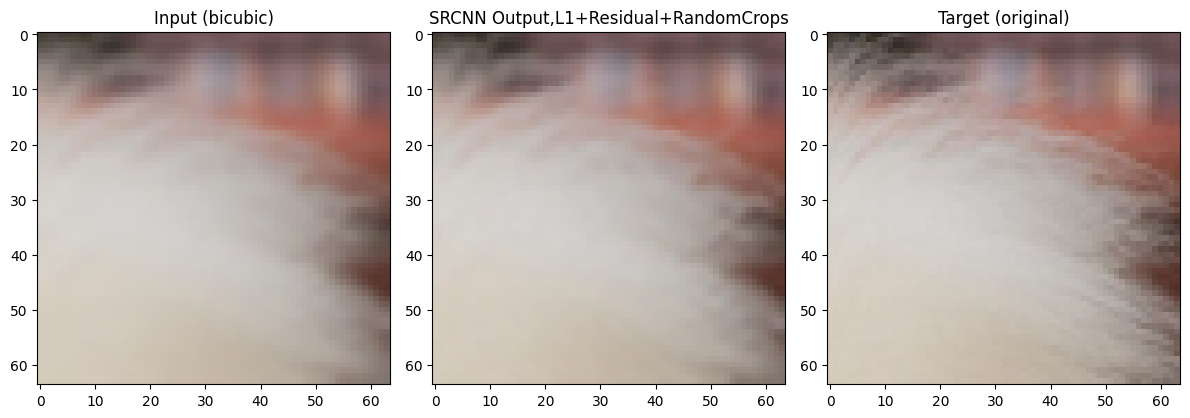

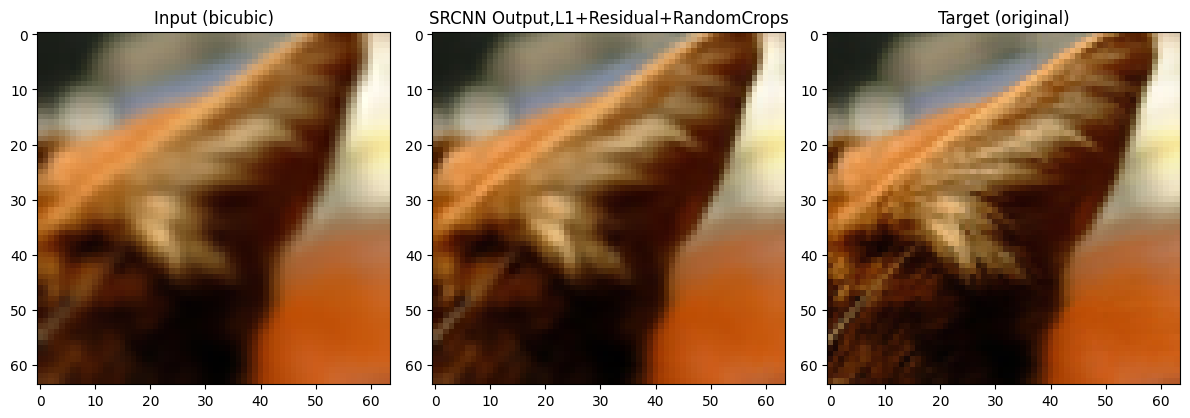

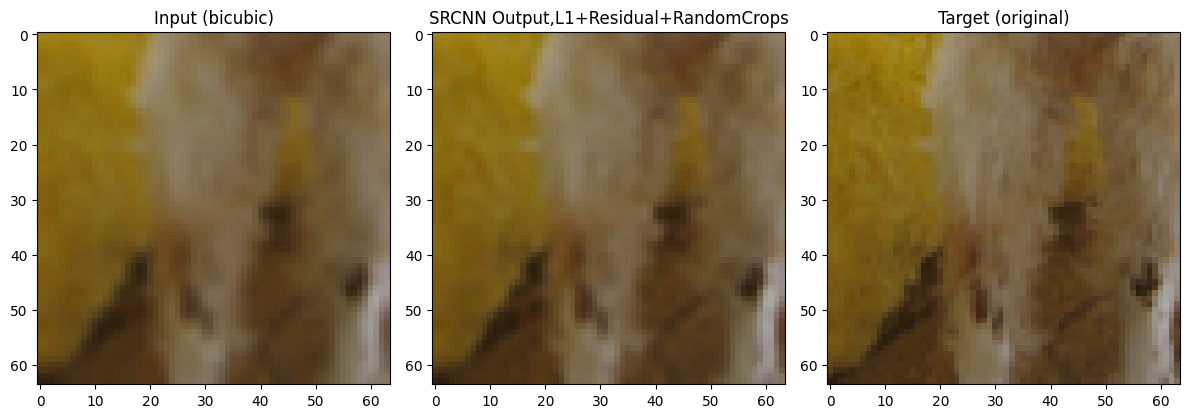

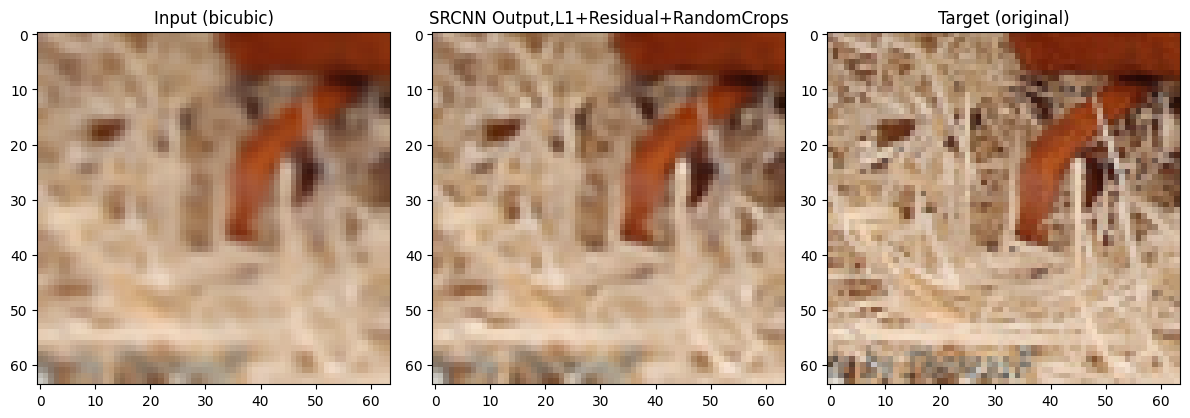

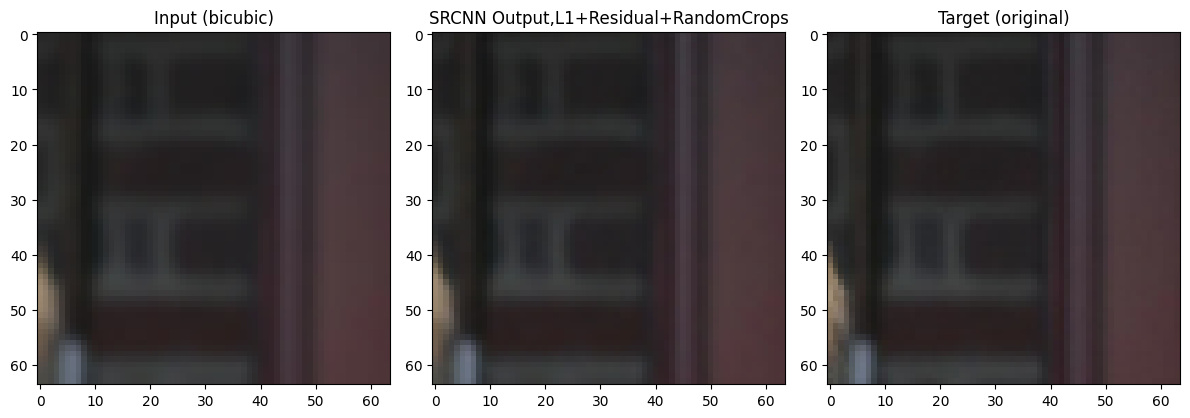

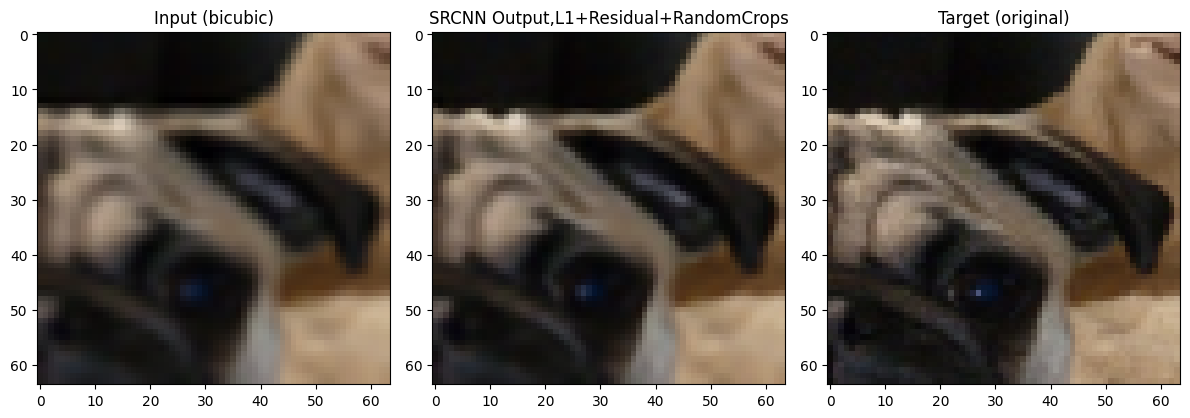

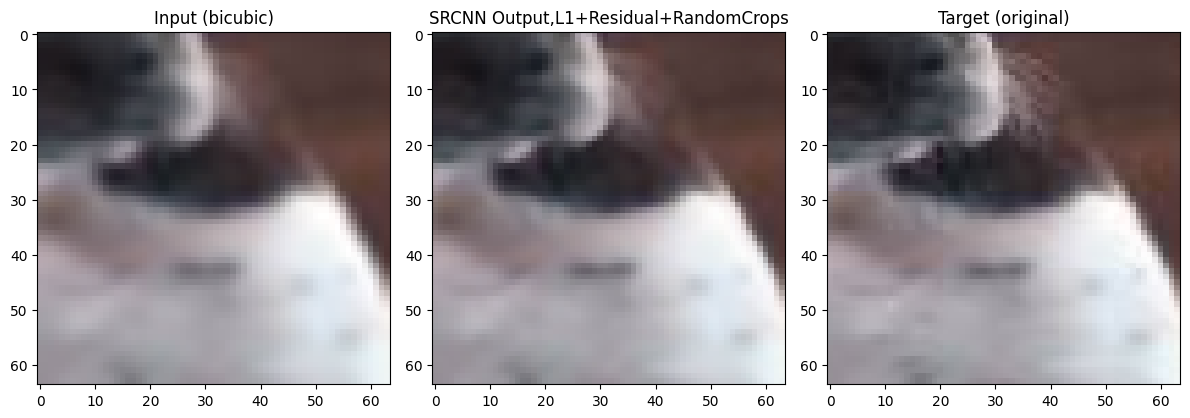

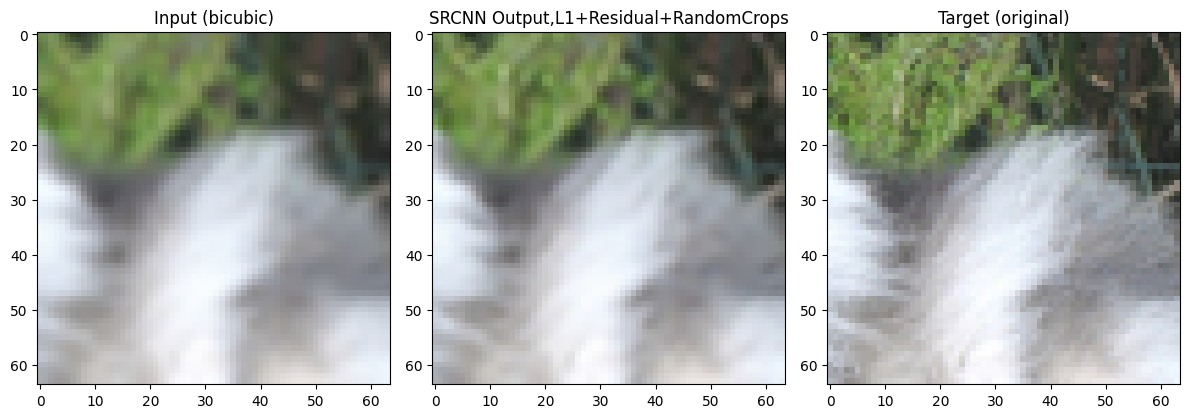

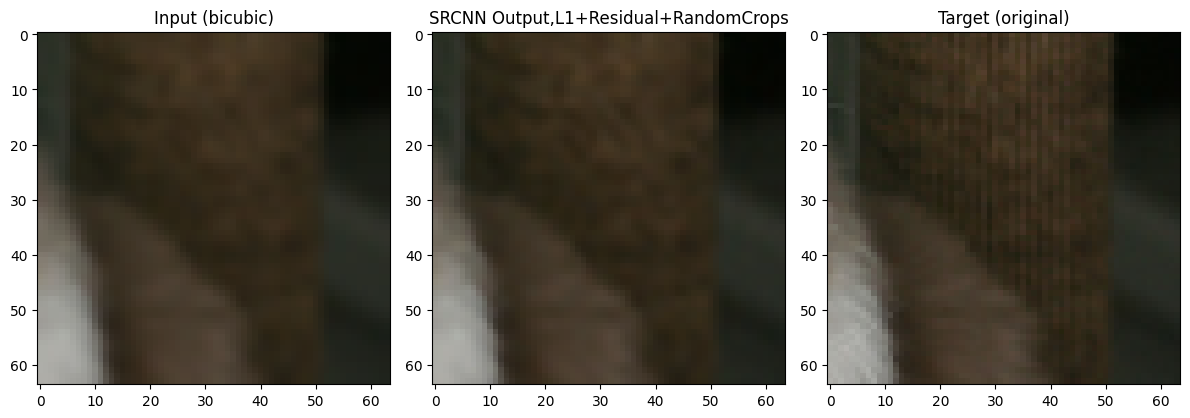

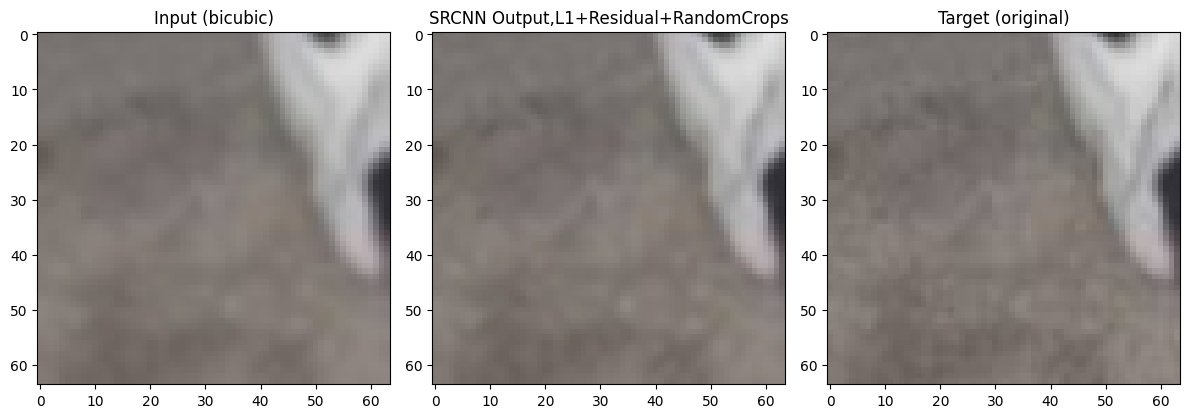

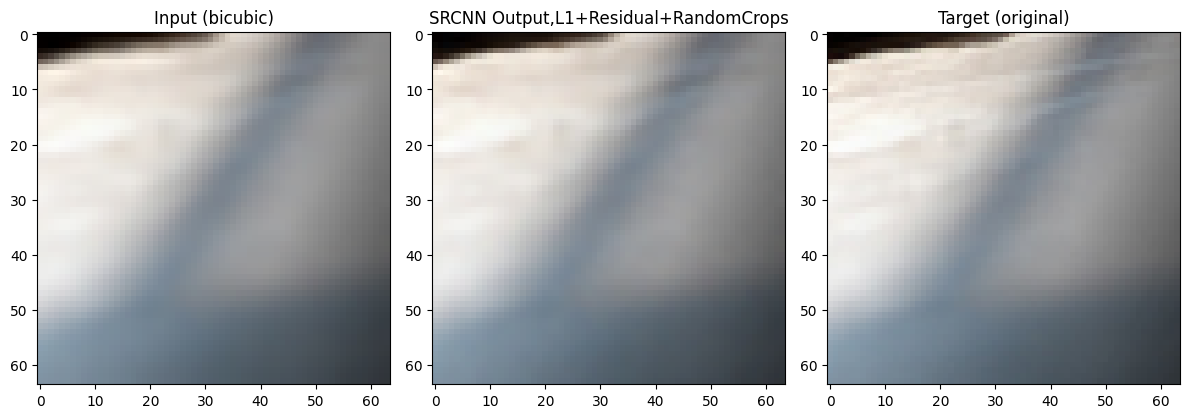

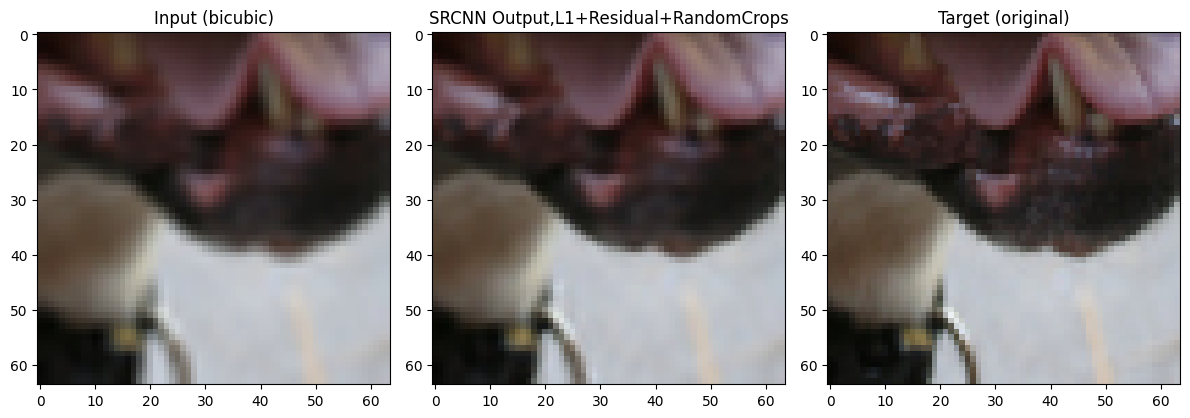

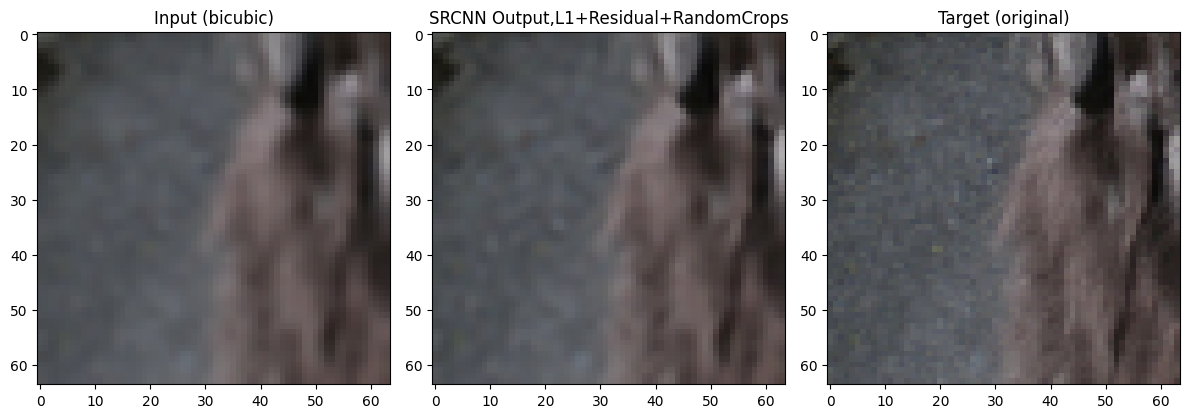

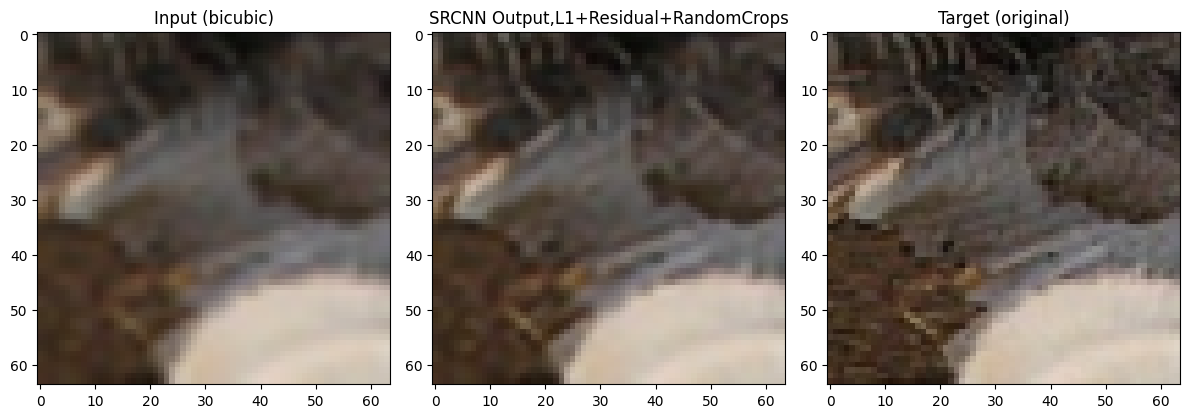

In [84]:
for i in range(inputs.shape[0]):
    idx = i # which image in the batch to show
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    axes[0].imshow(inputs[idx].float().cpu().permute(1, 2, 0).clamp(0, 1))
    axes[0].set_title("Input (bicubic)")

    axes[1].imshow(outputs[idx].float().cpu().detach().permute(1, 2, 0).clamp(0, 1))
    axes[1].set_title("SRCNN Output,L1+Residual+RandomCrops")

    axes[2].imshow(targets[idx].float().cpu().permute(1, 2, 0).clamp(0, 1))
    axes[2].set_title("Target (original)")

    plt.tight_layout()
    plt.show()


In [86]:
print(f"Output min: {outputs[idx].min().item():.4f}")
print(f"Output max: {outputs[idx].max().item():.4f}")

Output min: 0.0898
Output max: 0.9991
